In [1]:
from __future__ import annotations
from pathlib import Path 

import yaml, json, os, sys

import numpy as np, matplotlib.pyplot as plt
import igraph as ig, networkx as nx
import torch

from collections import deque 
from matplotlib.ticker import MultipleLocator, FuncFormatter
import matplotlib.colors as mcolors


ROOT = "/scratch/sleonard/MoE_circuits"
sys.path.insert(0, ROOT)

with open(os.path.join(ROOT, "config.yaml")) as f:
    config = yaml.safe_load(f)

/scratch/sleonard/miniconda3/envs/megatron/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [4]:
MODELS   = ["olmoe", "deepseek-v2-lite"]
DATASETS = ["c4", "math", "code"]

dags: dict[MODELS, DATASETS] = {}
for m in MODELS:
    for d in DATASETS:
        path = os.path.join(config["result_path"], f"circuits/dag_{m}_{d}.pt")
        dags[(m, d)] = torch.load(path, map_location="cpu")

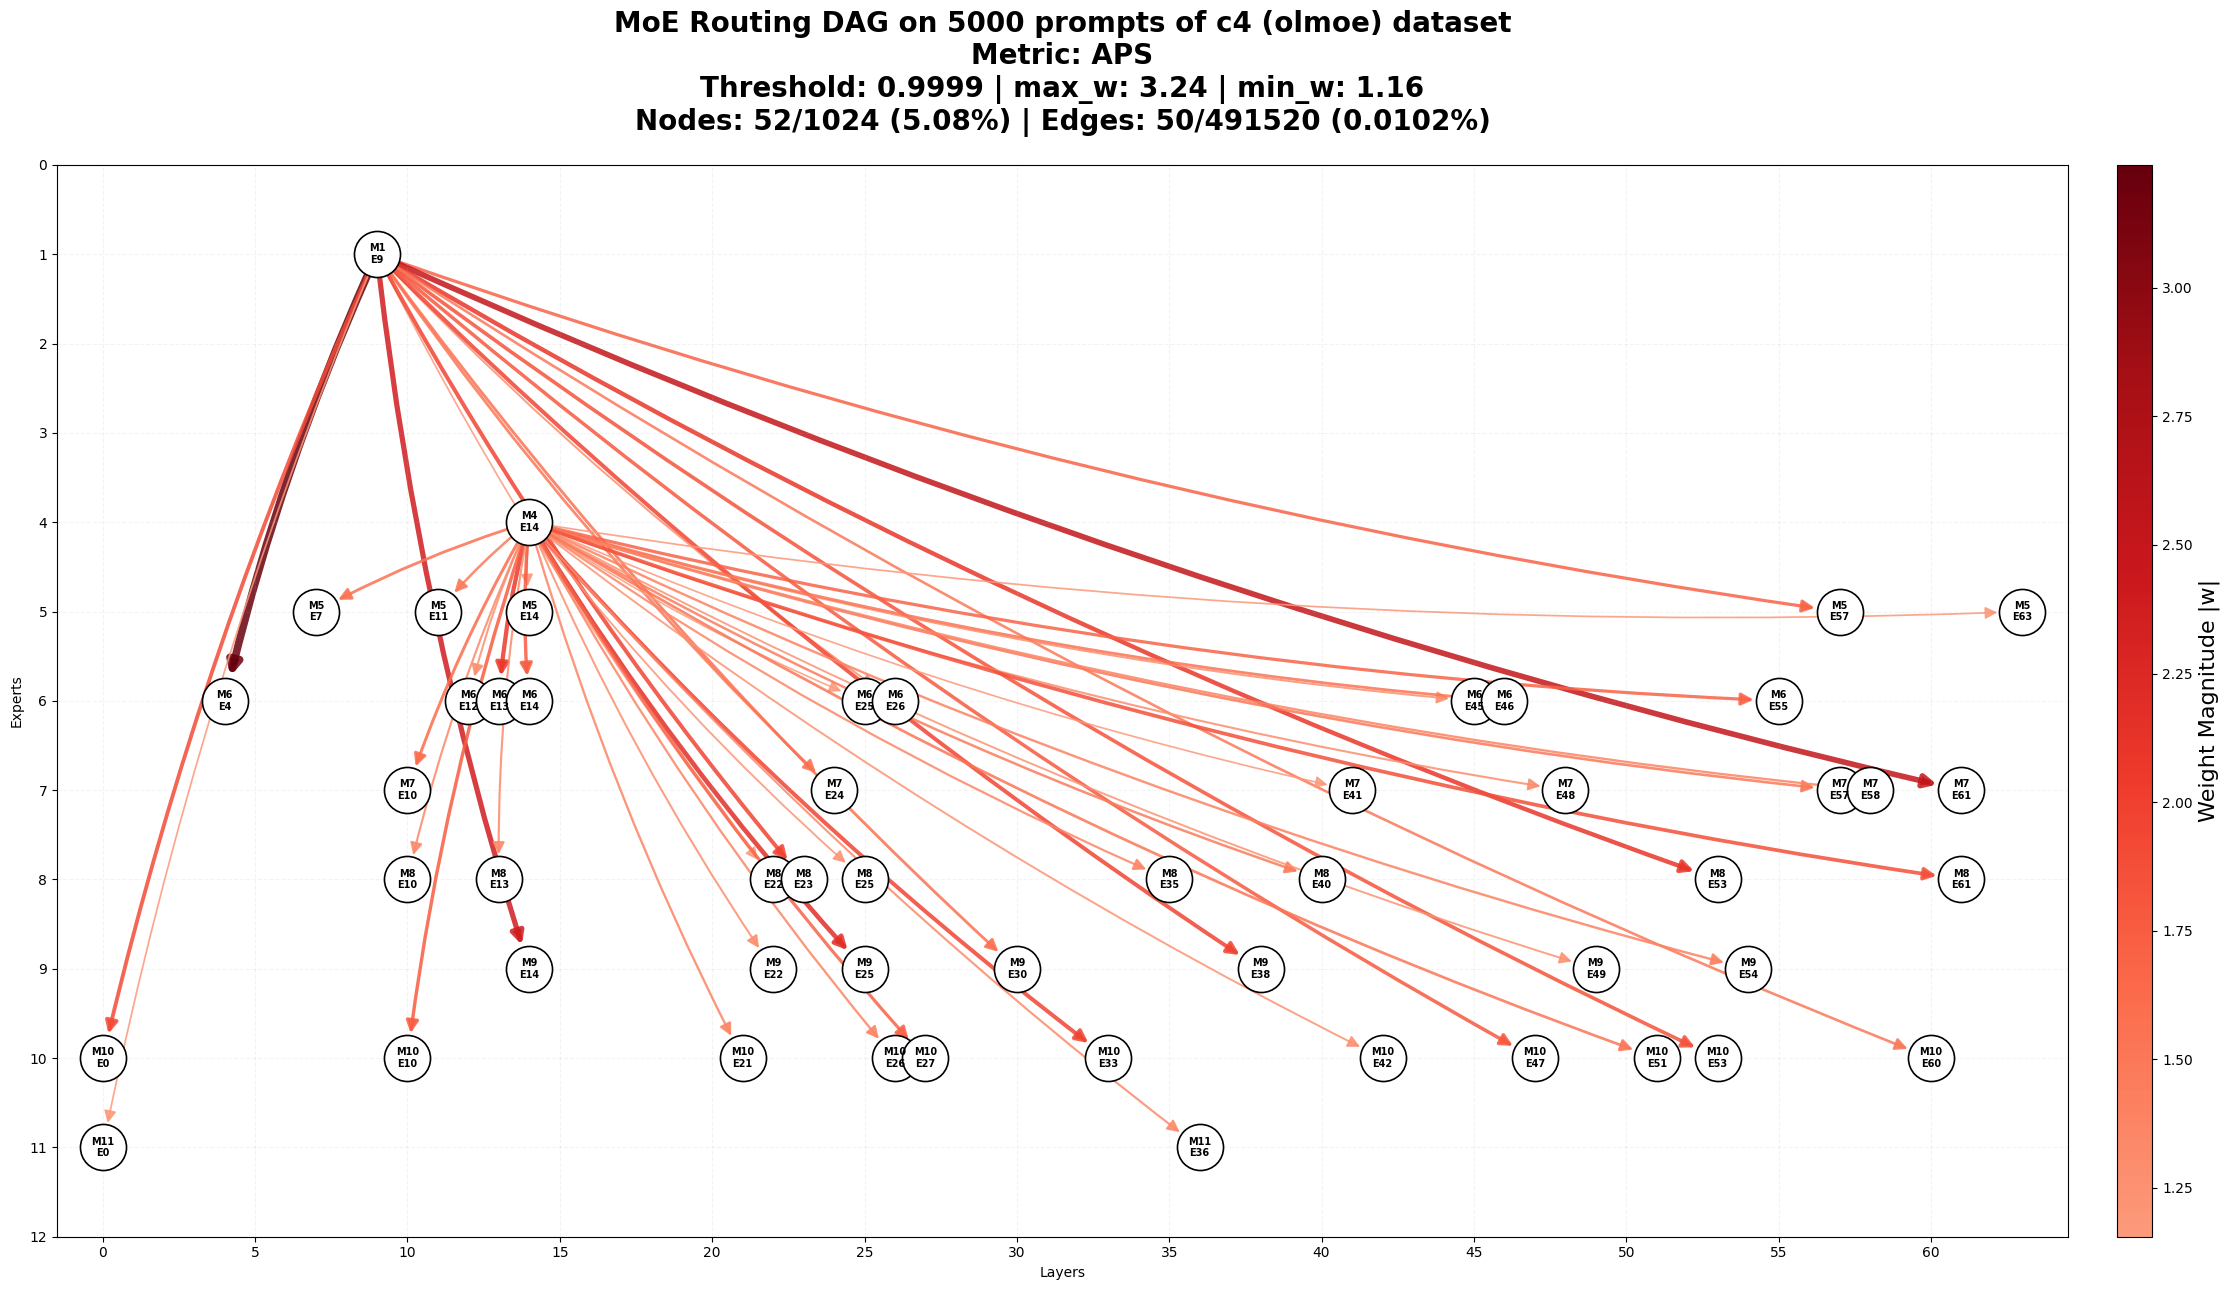

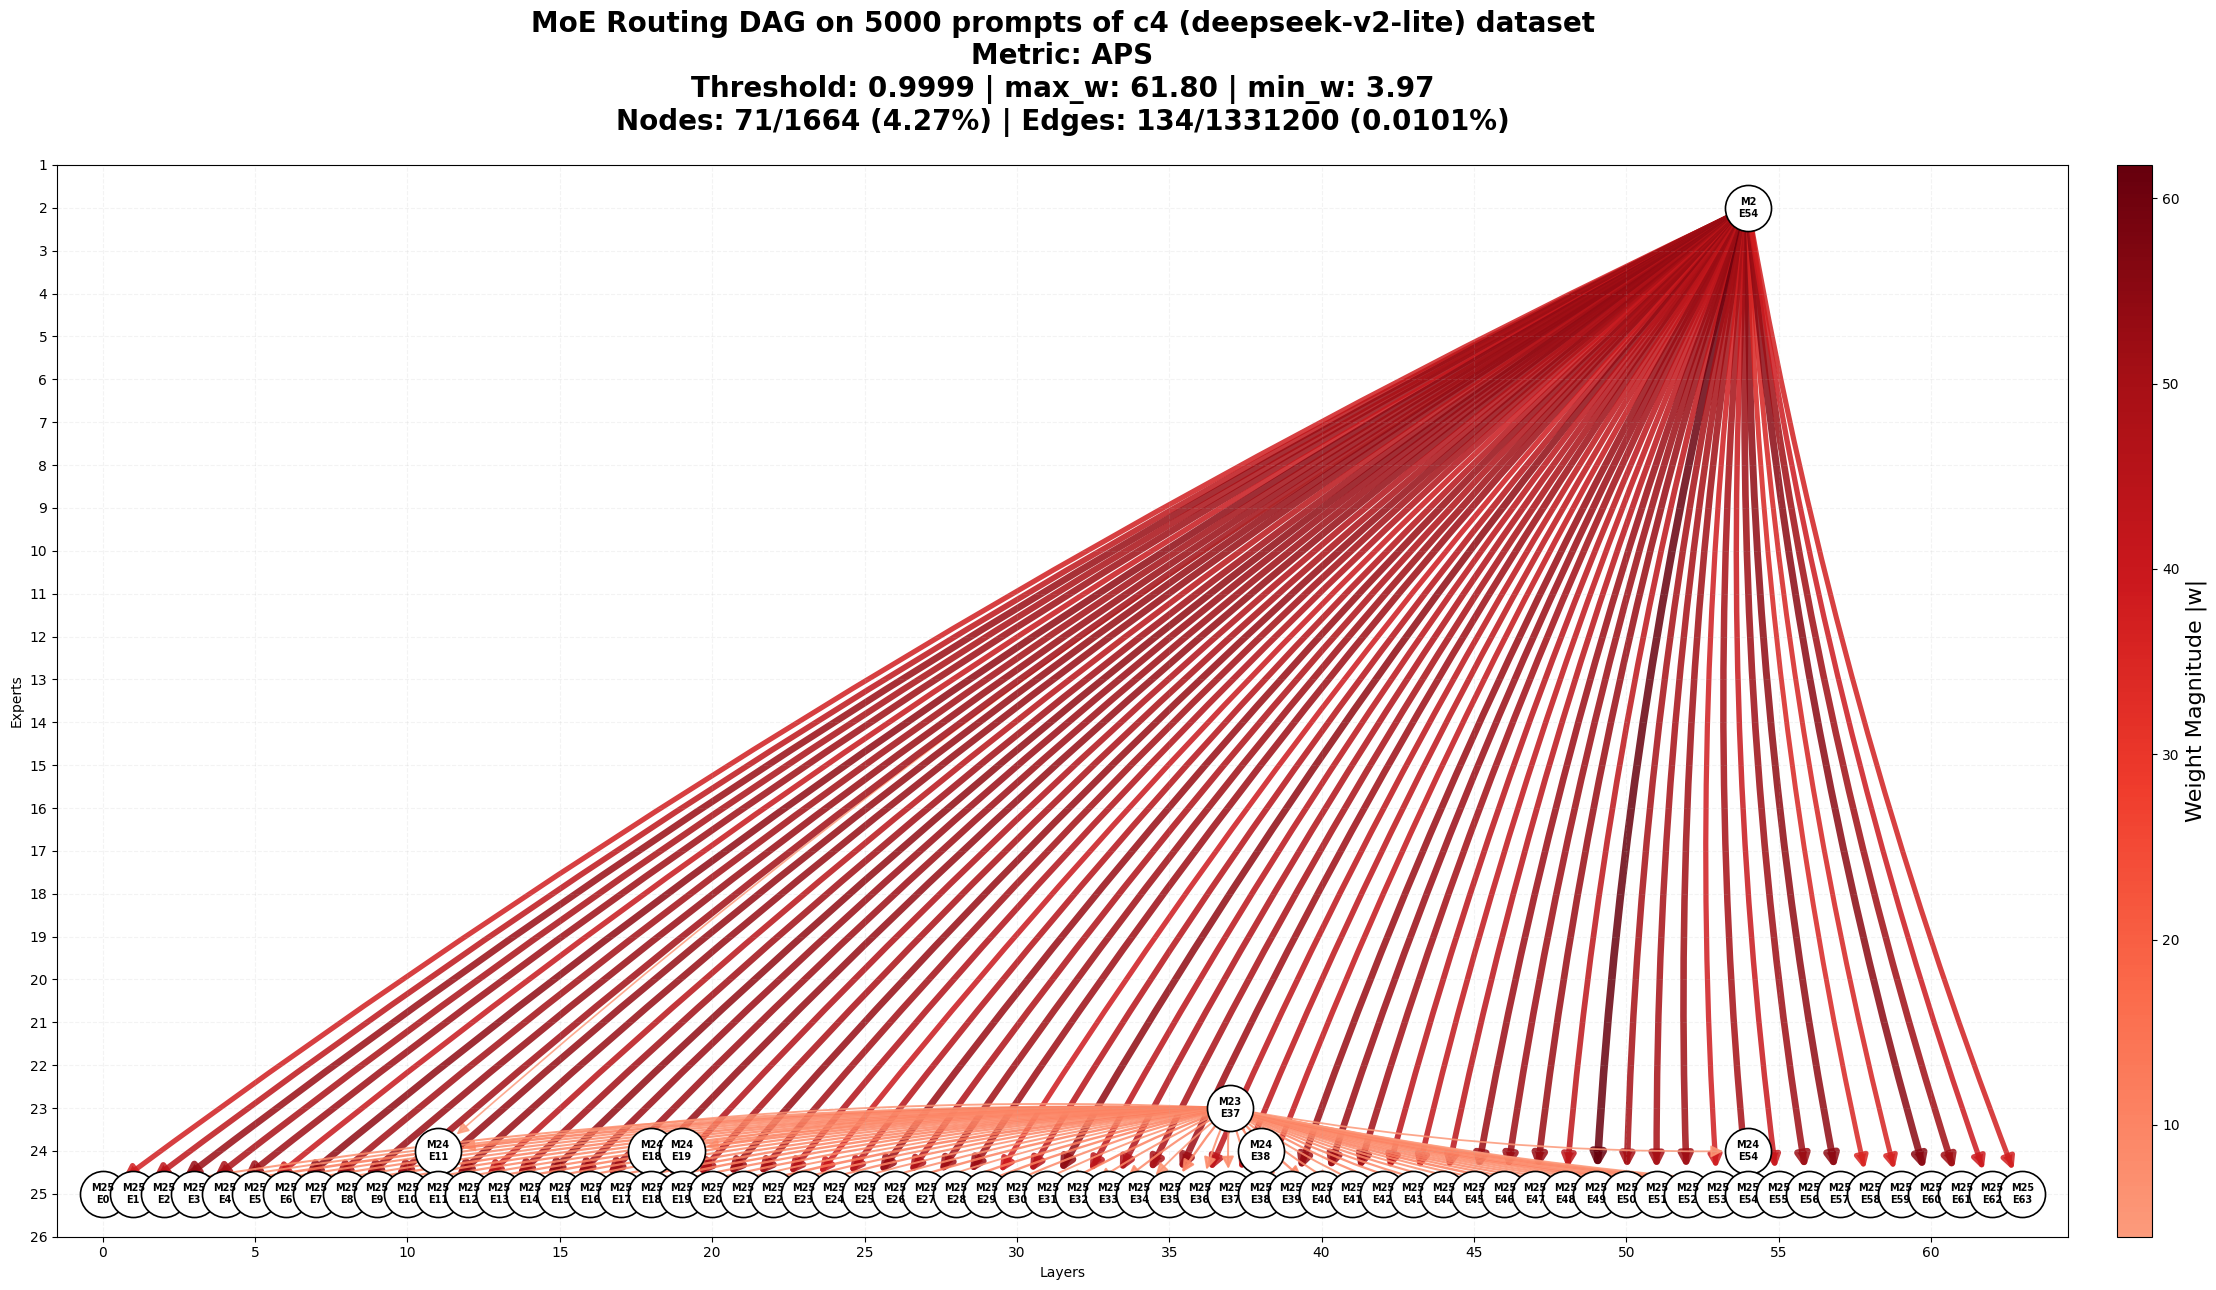

In [ ]:
from experiments.circuits.helper import get_thresholds, thresholding_routing_graph, show_enhanced_layered_graph

TARGET, Q = "APS", 0.9999
for m in MODELS:
    dag = dags[(m, "math")]
    t = get_thresholds(dag, TARGET, [Q])[Q]
    g = thresholding_routing_graph(dag, TARGET, t)
    show_enhanced_layered_graph(g, quantile=Q, target=TARGET, model=m, dataset="c4", n_prompts=dag["n_prompts"])

In [21]:
# --- Size-invariant spectral fingerprint ---
# For each DAG, take APS as the adjacency matrix (non-negative).
# Top-K singular values give a length-K vector that doesn't depend on N = L*E.
# Cosine sim of two such vectors is invariant to (a) within-layer expert
# permutation and (b) overall scale.
WEIGHT, K = "APS", 64

specs = {}
for key, dag in dags.items():
    W = dag[WEIGHT]
    if isinstance(W, torch.Tensor):
        W = W.cpu().numpy().astype(np.float64)
    L, E = W.shape[0], W.shape[1]
    A = W.reshape(L * E, L * E)
    s = np.linalg.svd(A, compute_uv=False)  # descending
    specs[key] = s[:K]
    print(f"{key}: N={L*E:>5d}  sigma_1={s[0]:.3g}  sigma_{K}={s[K-1]:.3g}")

('olmoe', 'c4'): N= 1024  sigma_1=12.3  sigma_64=0.292
('olmoe', 'math'): N= 1024  sigma_1=13.7  sigma_64=0.29
('olmoe', 'code'): N= 1024  sigma_1=7.52  sigma_64=0.265
('deepseek-v2-lite', 'c4'): N= 1664  sigma_1=402  sigma_64=0.462
('deepseek-v2-lite', 'math'): N= 1664  sigma_1=396  sigma_64=0.497
('deepseek-v2-lite', 'code'): N= 1664  sigma_1=131  sigma_64=0.515


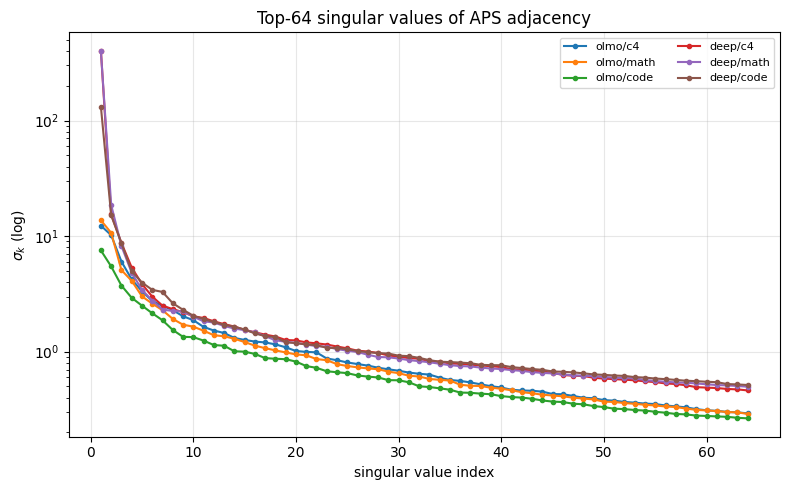

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
for key, s in specs.items():
    ax.semilogy(np.arange(1, K + 1), s, marker="o", markersize=3, label=f"{key[0][:4]}/{key[1]}")
ax.set_xlabel("singular value index")
ax.set_ylabel(r"$\sigma_k$ (log)")
ax.set_title(f"Top-{K} singular values of {WEIGHT} adjacency")
ax.legend(ncol=2, fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

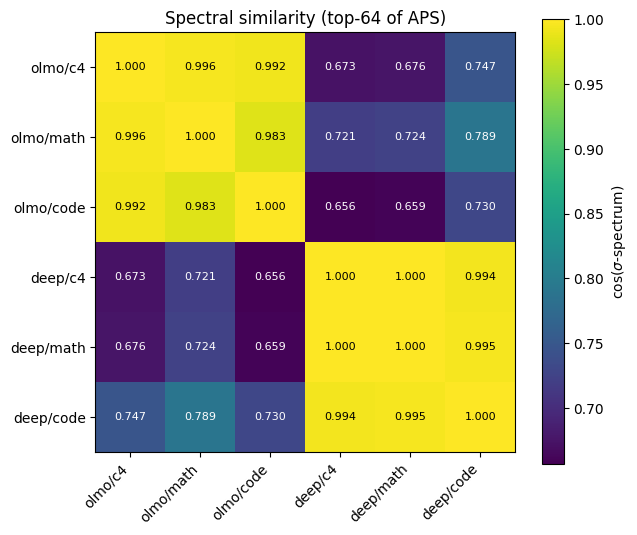

In [23]:
# --- 6x6 similarity matrix: cosine of singular-value spectra ---
keys = list(dags.keys())
n = len(keys)
SIM = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        si, sj = specs[keys[i]], specs[keys[j]]
        SIM[i, j] = (si @ sj) / (np.linalg.norm(si) * np.linalg.norm(sj))

labels = [f"{k[0][:4]}/{k[1]}" for k in keys]
fig, ax = plt.subplots(figsize=(6.5, 5.5))
off_diag = SIM[~np.eye(n, dtype=bool)]
vmin = float(off_diag.min())
im = ax.imshow(SIM, cmap="viridis", vmin=vmin, vmax=1.0)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha="right"); ax.set_yticklabels(labels)
mid = (vmin + 1.0) / 2
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{SIM[i,j]:.3f}", ha="center", va="center",
                color="white" if SIM[i, j] < mid else "black", fontsize=8)
fig.colorbar(im, ax=ax, label=r"cos($\sigma$-spectrum)")
ax.set_title(f"Spectral similarity (top-{K} of {WEIGHT})")
plt.tight_layout(); plt.show()

In [24]:
# --- Block aggregates ---
# Platonic-Hypothesis support pattern (what we hope to see):
#     CMS (cross-model same-dataset) >> CMD (cross-model different-dataset) >> null
# Secondary check: CMS ~ WM (within-model cross-dataset). If CMS << WM, routing
# is model-architecture-specific rather than task-driven.

def block_mean(rows, cols, exclude_diag=False):
    vals = [SIM[i, j] for i in rows for j in cols if not (exclude_diag and i == j)]
    return float(np.mean(vals))

olmoe_idx = [i for i, k in enumerate(keys) if k[0] == "olmoe"]
dpsk_idx  = [i for i, k in enumerate(keys) if k[0] == "deepseek-v2-lite"]

WM_olmoe = block_mean(olmoe_idx, olmoe_idx, exclude_diag=True)
WM_dpsk  = block_mean(dpsk_idx,  dpsk_idx,  exclude_diag=True)
CMS = float(np.mean([SIM[i, j] for i in olmoe_idx for j in dpsk_idx if keys[i][1] == keys[j][1]]))
CMD = float(np.mean([SIM[i, j] for i in olmoe_idx for j in dpsk_idx if keys[i][1] != keys[j][1]]))

print(f"WM_olmoe (within OLMoE,    cross-dataset)  : {WM_olmoe:.3f}")
print(f"WM_dpsk  (within DeepSeek, cross-dataset)  : {WM_dpsk:.3f}")
print(f"CMS      (cross-model, same-dataset)       : {CMS:.3f}   <-- headline")
print(f"CMD      (cross-model, different-dataset)  : {CMD:.3f}")

WM_olmoe (within OLMoE,    cross-dataset)  : 0.990
WM_dpsk  (within DeepSeek, cross-dataset)  : 0.996
CMS      (cross-model, same-dataset)       : 0.709   <-- headline
CMD      (cross-model, different-dataset)  : 0.708


In [25]:
# --- Frobenius diagnostic: is there any task signal in the aggregate? ---
# WM ~ 0.99 from the sigma-spectrum says "spectra look the same across datasets
# within a model." That metric is coarse; this cell asks the raw question:
# how different are the APS tensors themselves across datasets within a model?
#
# Interpretation guide:
#   < 0.05  -> aggregate routing is essentially task-invariant
#   > 0.20  -> substantial task signal exists; sigma-spectrum metric is too coarse
#   in between -> ambiguous, look at per-edge difference distribution next

def relfro(A_t, B_t):
    A = A_t.cpu().numpy().astype(np.float64)
    B = B_t.cpu().numpy().astype(np.float64)
    return float(np.linalg.norm(A - B) / np.linalg.norm(A))

print(f"Within-model relative Frobenius distance ({WEIGHT}):\n")
for m in MODELS:
    for d1, d2 in [("c4", "math"), ("c4", "code"), ("math", "code")]:
        r = relfro(dags[(m, d1)][WEIGHT], dags[(m, d2)][WEIGHT])
        print(f"  {m:<20s}  {d1:<4s} <-> {d2:<4s}: {r:.3f}")
    print()

Within-model relative Frobenius distance (APS):

  olmoe                 c4   <-> math: 0.268
  olmoe                 c4   <-> code: 0.505
  olmoe                 math <-> code: 0.533

  deepseek-v2-lite      c4   <-> math: 0.046
  deepseek-v2-lite      c4   <-> code: 0.755
  deepseek-v2-lite      math <-> code: 0.742

